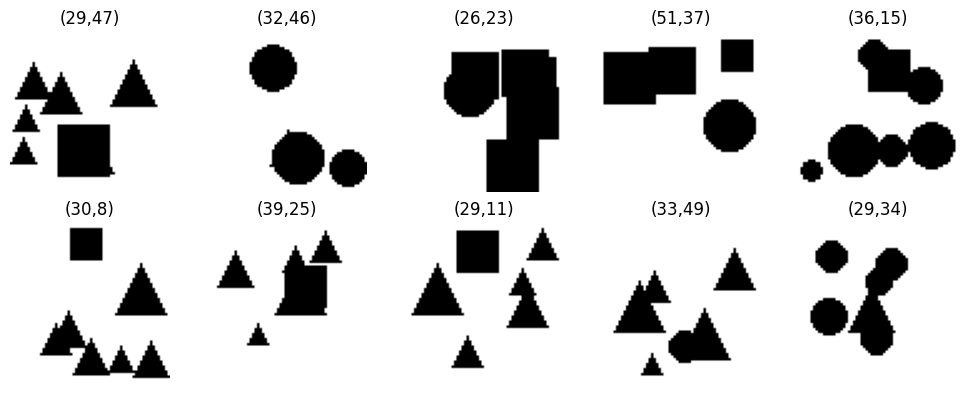

In [11]:
import torch, random, math, numpy as np
import torch.nn.functional as F
from PIL import Image, ImageDraw
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
#device = torch.device("cpu")

IMAGE = 64
SHAPES = ("circle", "square", "triangle")

def draw_shape(drawer, shape_type, center_x, center_y, radius):
  if shape_type == "circle":
    drawer.ellipse([center_x - radius, center_y - radius,
                        center_x + radius, center_y + radius], fill="black")
  elif shape_type == "square":
    drawer.rectangle([center_x - radius, center_y - radius,
                          center_x + radius, center_y + radius], fill="black")
  else:  # triangle
    drawer.polygon([
        (center_x, center_y - radius),
        (center_x - radius, center_y + radius),
        (center_x + radius, center_y + radius)
    ], fill="black")

class OddXYDataset(torch.utils.data.Dataset):
    """
    Generates images on-the-fly:
      * several random shapes of the same type
      * 1 additional shape of a different type
    Returns:
      * image (1×64×64 tensor, float32 normalized to [0,1])
      * label: float tensor [cx, cy] with center of the odd shape
    Arguments:
        num_samples             – total number of samples in the dataset
        same_shape_count_range – tuple (min, max), number of identical shapes
        shape_radius_range      – tuple (min_radius, max_radius) for shape size
    """
    def __init__(self,
                 num_samples,
                 same_shape_count_range=(3, 6),
                 shape_radius_range=(4, 10)):
      self.num_samples = num_samples
      self.same_shape_count_range = same_shape_count_range
      self.radius_min, self.radius_max = shape_radius_range

    def __len__(self):
      return self.num_samples

    def __getitem__(self, idx):
      base_shape = random.choice(SHAPES)
      odd_shape = random.choice([s for s in SHAPES if s != base_shape])

      img = Image.new("L", (IMAGE, IMAGE), "white")
      drawer = ImageDraw.Draw(img)

        # draw identical shapes
      for _ in range(random.randint(*self.same_shape_count_range)):
        radius = random.randint(self.radius_min, self.radius_max)
        cx = random.randint(radius, IMAGE - radius - 1)
        cy = random.randint(radius, IMAGE - radius - 1)
        draw_shape(drawer, base_shape, cx, cy, radius)

        # draw the odd shape (with known center)
      radius = random.randint(self.radius_min, self.radius_max)
      cx = random.randint(radius, IMAGE - radius - 1)
      cy = random.randint(radius, IMAGE - radius - 1)
      draw_shape(drawer, odd_shape, cx, cy, radius)

      img_tensor = torch.tensor(np.array(img), dtype=torch.float32).unsqueeze(0) / 255.
      label_tensor = torch.tensor([float(cx), float(cy)], dtype=torch.float32)
      return img_tensor, label_tensor

def show_examples(num_examples=10):
  """
  Displays a grid of image samples from OddXYDataset using a DataLoader with batch_size=1.

  Args:
      num_examples (int): Number of examples to display.
  """
  dataset = OddXYDataset(num_samples=num_examples)
  dataloader = torch.utils.data.DataLoader(dataset, batch_size=1, shuffle=False)

  num_columns = 5
  num_rows = math.ceil(num_examples / num_columns)

  fig, axes = plt.subplots(num_rows, num_columns, figsize=(num_columns * 2, num_rows * 2))

  for i, (image, label) in enumerate(dataloader):
    if i >= num_examples:
      break
    image_np = image.squeeze(0).squeeze(0).numpy()  # B=1,C=1,H,W --> H,W
    cx, cy = label.squeeze(0)                       # B=1,2       --> 2
    axes.flat[i].imshow(image_np, cmap="gray")
    axes.flat[i].set_title(f"({cx:.0f},{cy:.0f})")
    axes.flat[i].axis("off")

  for j in range(i + 1, num_rows * num_columns):
    axes.flat[j].axis("off")

  plt.tight_layout()
  plt.show()


show_examples()

## Seeds for everything

In [12]:
def seed_everything(seed=41):
  random.seed(seed)
  torch.manual_seed(seed)
  torch.cuda.manual_seed(seed)
  torch.cuda.manual_seed_all(seed)

seed_everything()

## Training function

In [26]:
from time import time

def train_model(net, num_epochs=60):
  print(f"Working on {device}")
  net = net.to(device)

  criterion = torch.nn.MSELoss()
  optimizer = torch.optim.AdamW(net.parameters(), lr=1e-3)
  scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

  history = []
  start_time = time()

  for epoch in range(1, num_epochs + 1):
    net.train()
    running_loss = 0.0

    epoch_dataset = OddXYDataset(num_samples=25000)
    dataloader = torch.utils.data.DataLoader(epoch_dataset, batch_size=128, shuffle=False)

    for imgs, labels in dataloader:
      imgs = imgs.to(device)
      labels = labels.to(device)

      optimizer.zero_grad()
      preds, _ = net(imgs)

      loss = criterion(preds, labels)
      loss.backward()
      optimizer.step()
      running_loss += loss.item() * imgs.size(0)

    scheduler.step()
    epoch_rmse = math.sqrt(running_loss / 25000)
    history.append(epoch_rmse)

    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch:02d}/{num_epochs} | RMSE={epoch_rmse:.4f} px | "
          f"lr: {current_lr:.2e}")

  end_time = time()
  print(f"Elapsed time: {end_time - start_time:.2f}s")

  return history

## Plotting function

In [27]:
def plot_training_curve(train_rmse_history):
  plt.figure(figsize=(9, 5))

  plt.plot(train_rmse_history, label='Model RMSE', color='blue')

  plt.axhline(y=5.0, color='orange', linestyle='--', label='Level to pass (5.0 px)')
  plt.axhline(y=3.0, color='green', linestyle='--', label='Bonus level (3.0 px)')

  plt.title('Learning curve')
  plt.xlabel('Epoch')
  plt.ylabel('RMSE [px]')
  plt.grid(True, alpha=0.3)
  plt.legend()
  plt.show()

## Net construction

#### Field Centers Embedding

The proposed architecture processes an input image of size $64 \times 64$ pixels with a single channel using a Convolutional Neural Network (CNN) layer. The convolutional layer utilizes a kernel size of $20$ and a stride of $4$, producing a feature map of shape $32 \times 12 \times 12$. This spatial feature map is subsequently flattened and transposed into a sequence of $n = 144$ embeddings within a $d = 32$ dimensional feature space, represented as a matrix $F \in \mathbb{R}^{n \times d}$.

I used sinusoidal position encoding, but split the positional space into even halfes for $x$ any $y$ coordinates.

#### Self Attention

To capture global dependencies, a Self-Attention mechanism is introduced. Let $W_Q, W_K \in \mathbb{R}^{d \times k}$ and $W_V \in \mathbb{R}^{d \times d}$ denote the learnable projection matrices, where $k = 16$ represents the dimensionality of the query and key spaces. The queries $Q \in \mathbb{R}^{n \times k}$, keys $K \in \mathbb{R}^{n \times k}$, and values $V \in \mathbb{R}^{n \times d}$ are obtained via linear projections: $Q = FW_Q$, $K = FW_K$, and $V = FW_V$. The scaled energy matrix $E \in \mathbb{R}^{n \times n}$ is computed as

\begin{equation}
    E = \frac{QK^T}{\sqrt{k}} = \frac{FW_Q W_K^T F^T}{\sqrt{k}}.
\end{equation}

Given that $k < d$, the inner product $W_Q W_K^T$ restricts the maximum rank of the energy matrix to $\mathrm r(E) \le k = 16$, establishing a low-rank attention bottleneck. Applying a row-wise softmax yields the attention weight matrix $A = \mathrm{softmax}(E) \in \mathbb{R}^{n \times n}$.

The final output of the attention block is updated using a residual connection, resulting in $\tilde F = F + AV$.

### Prediction

The final stage performs coordinate prediction via a position-aware post-processing block. I did not use relu on $\tilde F$ here. A 3-layer MLP processes the attended features ($32 \rightarrow 128 \rightarrow 64 \rightarrow 1$) to score the importance of each embedding, outputting a logit vector $l \in \mathbb{R}^n$.

We transform these logits into a spatial probability distribution $w = \mathrm{softmax}(l)$.

Finally, the target coordinates $p \in \mathbb{R}^2$ are determined using a differentiable soft-argmax operator

\begin{equation}
    p = w C,
\end{equation}

where $C \in \mathbb{R}^{n \times 2}$ represents the fixed matrix of the underlying convolutional layer's receptive field centers.

In [1]:
def sinusoid_positions_2d(height=12, width=12, dim=32, B=1000):
  assert dim % 2 == 0, "It has to be even!"
  d_half = dim // 2

  y_coords = torch.arange(height).float().unsqueeze(1)
  x_coords = torch.arange(width).float().unsqueeze(1)

  i = torch.arange(d_half).float().unsqueeze(0)
  angle_rates = 1.0 / (B ** (2 * (i // 2) / d_half))

  angle_y = y_coords @ angle_rates
  angle_x = x_coords @ angle_rates

  PE_y = torch.zeros(height, d_half)
  PE_y[:, 0::2] = torch.sin(angle_y[:, 0::2])
  PE_y[:, 1::2] = torch.cos(angle_y[:, 1::2])

  PE_x = torch.zeros(width, d_half)
  PE_x[:, 0::2] = torch.sin(angle_x[:, 0::2])
  PE_x[:, 1::2] = torch.cos(angle_x[:, 1::2])

  PE = torch.zeros(height, width, dim)
  PE[:, :, :d_half] = PE_y.unsqueeze(1).repeat(1, width, 1)
  PE[:, :, d_half:] = PE_x.unsqueeze(0).repeat(height, 1, 1)

  return PE.view(height * width, dim).to(device)

In [29]:
feature_cnt = 32
hidden = 128
k = 16

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
S = sinusoid_positions_2d(height=16, width=16, dim=feature_cnt)

class PositionScorer(torch.nn.Module):
  def __init__(self, feature_cnt=32, hidden=128):
    super().__init__()

    self.firstLinear = torch.nn.Linear(feature_cnt, hidden)
    self.secondLinear = torch.nn.Linear(hidden, hidden // 2)
    self.thirdLinear = torch.nn.Linear(hidden // 2, 1)

  def forward(self, features):
    # [B, 144, 32]

    features = F.relu(self.firstLinear(features))
    # [B, 144, 128]

    features = F.relu(self.secondLinear(features))
    # [B, 144, 64]

    logits = self.thirdLinear(features)
    # [B, 144, 1]

    return logits


class FullSelfAttention(torch.nn.Module):
  def __init__(self, feature_cnt=32):
    super().__init__()

    self.q_project = torch.nn.Linear(feature_cnt, k)
    self.k_project = torch.nn.Linear(feature_cnt, k)
    self.v_project = torch.nn.Linear(feature_cnt, feature_cnt)

    self.scale = math.sqrt(k)

  def forward(self, features):
    # [B, 144, 32]

    Q = self.q_project(features)
    K = self.k_project(features)
    # [B, 144, 16]

    V = self.v_project(features)
    # [B, 144, 32]

    attn_scores = (Q @ K.transpose(-2, -1)) / self.scale
    # [B, 144, 144]

    weights = F.softmax(attn_scores, dim=-1)
    # [B, 144, 144]

    output = weights @ V
    # [B, 144, 32]

    return output, weights


class Net_SelfAttention_And_PE(torch.nn.Module):
  def __init__(self):
    super().__init__()

    self.conv = torch.nn.Conv2d(
        in_channels=1,
        out_channels=feature_cnt,
        kernel_size=20,
        stride=4
    )

    self.attention = FullSelfAttention(feature_cnt)
    self.pos_scorer = PositionScorer(feature_cnt, hidden)
    centers = torch.zeros(144, 2)

    idx = 0
    for r in range(12):
      for c in range(12):
        y_c = r * 4 + 9.5
        x_c = c * 4 + 9.5

        centers[idx] = torch.tensor([x_c, y_c])
        idx += 1

    self.register_buffer("rf_centers", centers)

  def forward(self, img):
    # [B, 1, 64, 64]

    features = F.relu(self.conv(img))
    # [B, 32, 12, 12]

    features = features.flatten(-2)
    # [B, 32, 144]

    features = features.transpose(-2, -1)
    # [B, 144, 32]

    features = features + S
    # [B, 144, 32]

    attended, weights = self.attention(features)
    # attended: [B, 144, 32]

    features = features + attended
    # [B, 144, 32]

    logits = self.pos_scorer(features)
    # [B, 144, 1]

    logits = logits.squeeze(-1)
    # [B, 144]

    probs = F.softmax(logits, dim=-1)
    # [B, 144]

    predicted_xy = probs @ self.rf_centers
    # [B, 2]

    return predicted_xy, weights

Working on cuda
Epoch 01/80 | RMSE=13.5496 px | lr: 1.00e-03
Epoch 02/80 | RMSE=12.9459 px | lr: 9.98e-04
Epoch 03/80 | RMSE=12.2455 px | lr: 9.97e-04
Epoch 04/80 | RMSE=11.3834 px | lr: 9.94e-04
Epoch 05/80 | RMSE=10.6092 px | lr: 9.90e-04
Epoch 06/80 | RMSE=10.1721 px | lr: 9.86e-04
Epoch 07/80 | RMSE=9.8677 px | lr: 9.81e-04
Epoch 08/80 | RMSE=9.6431 px | lr: 9.76e-04
Epoch 09/80 | RMSE=9.3538 px | lr: 9.69e-04
Epoch 10/80 | RMSE=9.2520 px | lr: 9.62e-04
Epoch 11/80 | RMSE=8.7671 px | lr: 9.54e-04
Epoch 12/80 | RMSE=8.3444 px | lr: 9.46e-04
Epoch 13/80 | RMSE=8.0813 px | lr: 9.36e-04
Epoch 14/80 | RMSE=7.7637 px | lr: 9.26e-04
Epoch 15/80 | RMSE=7.6266 px | lr: 9.16e-04
Epoch 16/80 | RMSE=7.4736 px | lr: 9.05e-04
Epoch 17/80 | RMSE=7.2552 px | lr: 8.93e-04
Epoch 18/80 | RMSE=7.0431 px | lr: 8.80e-04
Epoch 19/80 | RMSE=6.9635 px | lr: 8.67e-04
Epoch 20/80 | RMSE=6.9042 px | lr: 8.54e-04
Epoch 21/80 | RMSE=6.6462 px | lr: 8.39e-04
Epoch 22/80 | RMSE=6.4905 px | lr: 8.25e-04
Epoch 23/8

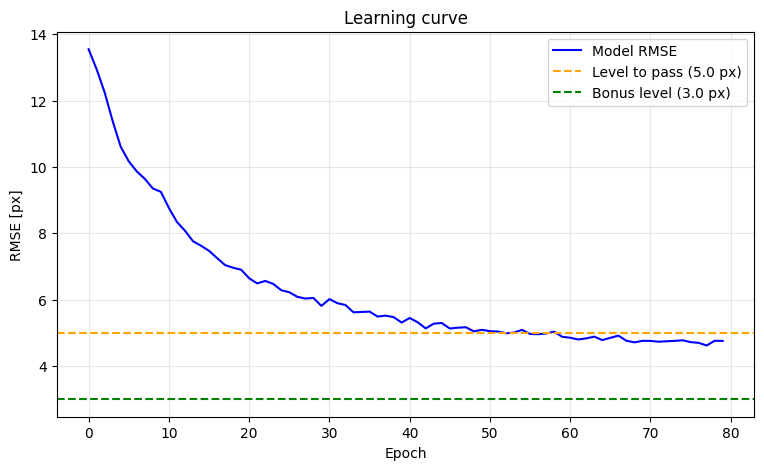

In [30]:
net = Net_SelfAttention_And_PE()
train_rmse_history = train_model(net, num_epochs=80)

plot_training_curve(train_rmse_history)

## Attention Visualization

In [31]:
import seaborn as sns

def visualize_attention_maps(net, dataset, sample_idx=0, device="cuda"):
  net.eval()

  img, label = dataset[sample_idx]
  img_input = img.unsqueeze(0).to(device)

  with torch.no_grad():
    predicted_xy, weights = net(img_input)

  attn_matrix = weights[0].cpu().numpy()

  fig = plt.figure(figsize=(16, 12))
  grid = plt.GridSpec(2, 3, wspace=0.3, hspace=0.3)

  ax_main = fig.add_subplot(grid[0, :])
  sns.heatmap(attn_matrix, ax=ax_main, cmap='viridis', cbar=True)
  ax_main.set_title("FullAttention matrice", fontsize=14)
  ax_main.set_xlabel("Key Index")
  ax_main.set_ylabel("Query Index")

  points_to_plot = [(0, 0), (5, 5), (11, 11)]
  for i, (r, c) in enumerate(points_to_plot):
    query_idx = r * 12 + c
    spatial_attn = attn_matrix[query_idx].reshape(12, 12)

    ax_sub = fig.add_subplot(grid[1, i])
    sns.heatmap(spatial_attn, ax=ax_sub, cmap='magma', cbar=True, square=True)

    ax_sub.scatter(c + 0.5, r + 0.5, color='cyan')

    ax_sub.set_title(f"What point ({r}, {c}) is looking at")
    ax_sub.set_xlabel("Grid X (12 columns)")
    ax_sub.set_ylabel("Grid Y (12 rows)")

  plt.suptitle(f"Self-Attention Visualizations (Sample #{sample_idx})", fontsize=18)
  plt.show()


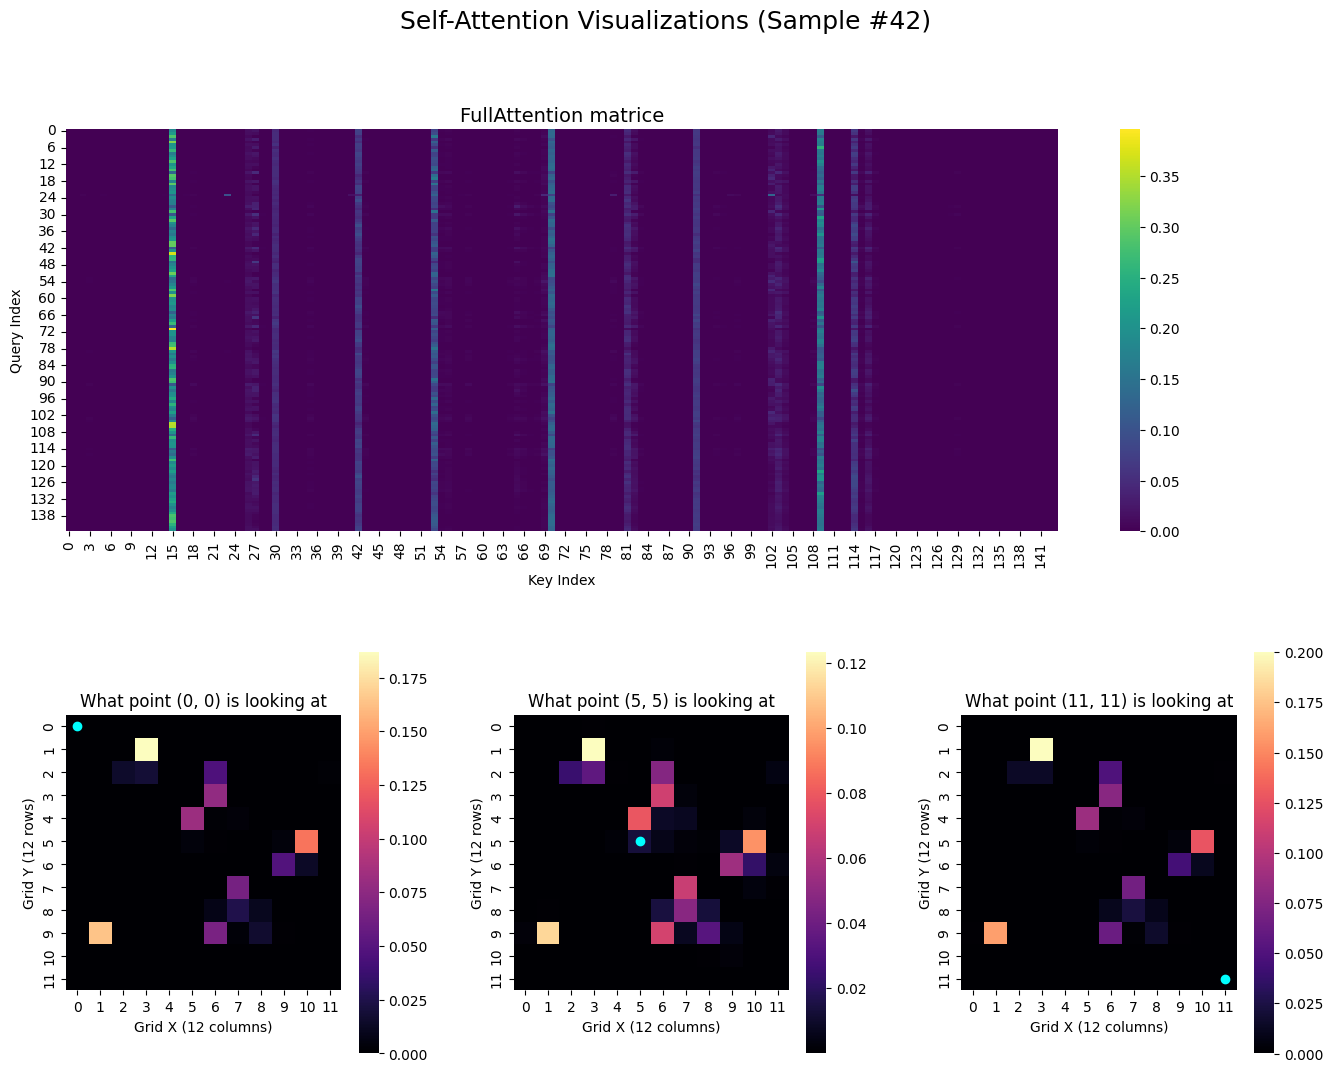

In [40]:
epoch_dataset = OddXYDataset(num_samples=25000)
visualize_attention_maps(net, epoch_dataset, sample_idx=42, device=device)

### Discussion

Since the objective of the network is explicit coordinate regression via a differentiable soft-argmax over the receptive field centers matrix $C$, the attention mechanism must capture robust geometric cues. Visualizing the attention weights reveals that the layer has converged on a global anchoring strategy.

The full attention matrix depicts clear vertical bands, meaning the attention distribution is independent of the query's spatial position. When projecting the attention rows back into the $12 \times 12$ spatial dimensions, queries from completely different areas (corners and center) yield almost identical activation topology. The network uniformly concentrates its attention budget on specific coordinates (e.g., the prominent peak at $X=3$).

This proves that the self-attention block effectively isolates the key features necessary for the PositionScorer MLP to generate an accurate probability distribution vector 2, validating the spatial reasoning capabilities of the architecture.